In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
import ResNet_18
%matplotlib inline


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),   
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])]) 

dataset = datasets.ImageFolder(root="C://Users//USER//Downloads//archive (2)//256_ObjectCategories", transform=transform)

remove_class_name = '256_ObjectCategories'
remove_idx = dataset.class_to_idx[remove_class_name]

In [4]:
valid_indices = [i for i, label in enumerate(dataset.targets) if label != remove_idx]
dataset.samples = [dataset.samples[i] for i in valid_indices]
dataset.targets = [dataset.targets[i] for i in valid_indices]
dataset.imgs = dataset.samples

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
target = dataset.targets
indices = np.arange(len(dataset))

train_idx, temp_idx = train_test_split(indices,test_size=0.3,stratify=target,random_state=42)
temp_targets = [target[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx,test_size=0.5,stratify=temp_targets,random_state=42)

train_dataset = Subset(dataset, train_idx)
valid_dataset = Subset(dataset, val_idx)
test_dataset  = Subset(dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(valid_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 21424
Validation samples: 4591
Test samples: 4592


In [8]:
print(len(val_loader))

144


In [11]:
criterion = nn.CrossEntropyLoss()
model = ResNet_18.ResNet18(n_classes=258)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate,weight_decay =0.005, momentum=0.9)
model.to(device)

def validation_test(model, valid_loader):
    total_loss = 0.0
    total_samples = 0
    
    with torch.no_grad():
        model.eval()
        for image, label in valid_loader:
            image, label = image.to(device), label.to(device)
            pred_label = model(image)
            loss = criterion(pred_label, label)
            
            batch_size = image.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

    return total_loss / total_samples

In [12]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    for batch_idx,(image,label) in enumerate(train_loader):
       
        image = image.to(device)
        label = label.to(device)

        pred_label = model(image)
        loss = criterion(pred_label,label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if batch_idx%500==0:
            validation_loss = validation_test(model,val_loader)   
            model.train()
            print(f"EPOCHS[{epoch+1}/{num_epochs}] : TRAINING LOSS {loss.item():.4f} : VALIDATION LOSS {validation_loss:.4f}")   

EPOCHS[1/10] : TRAINING LOSS 5.5835 : VALIDATION LOSS 5.5535
EPOCHS[1/10] : TRAINING LOSS 5.0115 : VALIDATION LOSS 4.7761
EPOCHS[2/10] : TRAINING LOSS 4.6155 : VALIDATION LOSS 4.7531
EPOCHS[2/10] : TRAINING LOSS 4.9054 : VALIDATION LOSS 4.5646
EPOCHS[3/10] : TRAINING LOSS 4.1411 : VALIDATION LOSS 4.6820
EPOCHS[3/10] : TRAINING LOSS 4.3208 : VALIDATION LOSS 4.2970
EPOCHS[4/10] : TRAINING LOSS 3.6029 : VALIDATION LOSS 4.1376
EPOCHS[4/10] : TRAINING LOSS 4.3450 : VALIDATION LOSS 4.1025
EPOCHS[5/10] : TRAINING LOSS 4.1272 : VALIDATION LOSS 4.1429
EPOCHS[5/10] : TRAINING LOSS 3.7120 : VALIDATION LOSS 3.8953
EPOCHS[6/10] : TRAINING LOSS 3.9267 : VALIDATION LOSS 3.9629
EPOCHS[6/10] : TRAINING LOSS 3.7771 : VALIDATION LOSS 3.8813
EPOCHS[7/10] : TRAINING LOSS 3.5818 : VALIDATION LOSS 3.7248
EPOCHS[7/10] : TRAINING LOSS 3.9316 : VALIDATION LOSS 3.7629
EPOCHS[8/10] : TRAINING LOSS 2.7348 : VALIDATION LOSS 3.7933
EPOCHS[8/10] : TRAINING LOSS 3.5003 : VALIDATION LOSS 3.5885
EPOCHS[9/10] : TRAINING 

In [13]:
def test_model(model,dataset,device):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0
    with torch.no_grad():
        for batch_idx,(test_image, test_label) in enumerate(dataset):

            image = test_image.to(device)
            label = test_label.to(device)

            pred_label = model(image)
            
            loss = criterion(pred_label,label)
            total_loss += loss.item()
            _, predicted = torch.max(pred_label, dim=1)
            
            total += label.size(0)
            correct += (predicted == label).sum().item()

    return correct/total, total_loss/len(dataset)      


In [14]:
training_accuracy, training_loss = test_model(model,train_loader,device)
validation_accuracy, validation_loss = test_model(model,val_loader,device)
testing_accuracy, testing_loss = test_model(model,test_loader,device)

print(f"Training Accuracy: {training_accuracy*100:.2f}%")
print(f"Validation Accuracy: {validation_accuracy*100:.2f}%")
print(f"Testing Accuracy: {testing_accuracy*100:.2f}%")

Training Accuracy: 29.42%
Validation Accuracy: 25.75%
Testing Accuracy: 25.85%


In [17]:
print(f"Training Loss: {training_loss:.4f}")
print(f"Validation Loss: {validation_loss:.4f}")
print(f"Testing Loss: {testing_loss:.4f}")

Training Loss: 3.1985
Validation Loss: 3.4748
Testing Loss: 3.4672


In [18]:
import cv2
from ResNet_18 import GradCam
def plot_gradcam(model, image_tensor, raw_dataset, target_layer, device):
    grad_cam = GradCam(model, target_layer)
    
    input_tensor = image_tensor.unsqueeze(0).to(device)
    
    heatmap, pred_class = grad_cam.generate_heatmap(input_tensor)
    
    orig_img = image_tensor.permute(1, 2, 0).cpu().numpy()
    
    heatmap_resized = cv2.resize(heatmap, (224,224))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)/255.0
    
    overlay = 0.6 * orig_img + 0.4 * heatmap_colored
    overlay = np.clip(overlay, 0, 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(orig_img)
    axes[0].set_title("Original Image")
    
    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title(f"Grad-CAM Heatmap")
    
    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay")
    
    for ax in axes:
        ax.axis('off')
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].


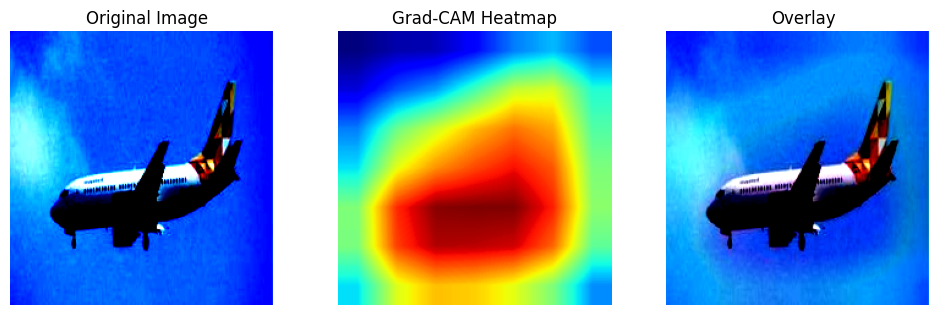

In [21]:

sample_img, sample_label = train_dataset[260]
plot_gradcam(model=model, image_tensor=sample_img, raw_dataset=train_dataset, target_layer=model.conv5_2_2, device=device)